In [1]:
import pandas as pd

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 20)

df = pd.read_csv('/workspaces/IESO/datasets/processed/merged_2025.csv', parse_dates=['Date'])
print(f"Rows: {len(df):,}  |  Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()

Rows: 8,759  |  Date range: 2025-01-01 → 2025-12-31


,Date,Hour,Month,Month_Name,Week,DayOfWeek,Total_Imp,Total_Exp,Total_Flow,Net_Export,Ontario_Demand,Market_Demand
0,2025-01-01,1,1,Jan,1,Wednesday,94,3502,3843,3408,13887,17247
1,2025-01-01,2,1,Jan,1,Wednesday,94,3774,4127,3680,13722,17355
2,2025-01-01,3,1,Jan,1,Wednesday,94,4129,4476,4035,13688,17638
3,2025-01-01,4,1,Jan,1,Wednesday,94,3587,4097,3493,13613,17065
4,2025-01-01,5,1,Jan,1,Wednesday,94,4071,4463,3977,13593,17498


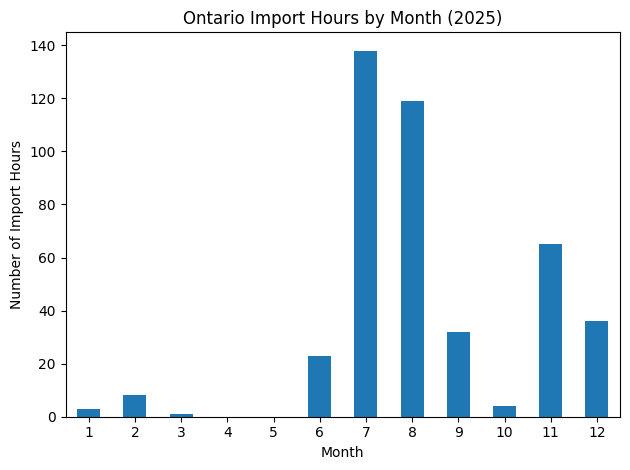

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/workspaces/IESO/datasets/processed/merged_2025.csv")

# Convert datetime column
df["Date"] = pd.to_datetime(df["Date"])

# Create month column
df["Month"] = df["Date"].dt.month

# Identify import hours (when imports > exports)
df["Import_Hour"] = df["Net_Export"] < 0

# Count import hours per month
monthly_imports = df.groupby("Month")["Import_Hour"].sum()

# Plot bar chart
plt.figure()
monthly_imports.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Number of Import Hours")
plt.title("Ontario Import Hours by Month (2025)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()